# Vortex Induced Vibrations


In [61]:
import numpy as np
import matplotlib.pyplot as plt


L = 50.0
D = 0.5
rho_w = 1025
rho_c = 7880
T = 30000
b = 126
St = 0.21

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a
omega_n = (np.pi / L) * np.sqrt(T / m_eff)
zeta = b / (2 * omega_n * m_eff)

epsilon = 0.3
A_coupling = 12.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0


In [62]:
def rhs(t, x, U):

    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    # Lift 
    Lift = 0.5 * rho_w * U**2 * D * L * q

    # Structural 
    y_ddot = (-2*zeta*omega_n*y_dot - omega_n**2*y + Lift/m_eff)

    # Wake 
    q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [63]:
def rk4(f, t, x, dt, U):

    k1 = f(t, x, U)
    k2 = f(t + dt/2, x + dt/2 * k1, U)
    k3 = f(t + dt/2, x + dt/2 * k2, U)
    k4 = f(t + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [64]:
def comp_x(dt, t_end, U):
    time = np.arange(0, t_end, dt)
    x = np.array([0.01, 0.0, 0.0, 0.0])
    solution = np.zeros((len(time), 4))

    for i, t in enumerate(time):
        solution[i] = x
        x = rk4(rhs, t, x, dt, U)

    return time, solution

In [65]:
def compute_amplitude(dt, t_end, U):

    time, solution = comp_x(dt , t_end, U)

    y = solution[:,2]

    # Remove transient (last 30%)
    cutoff = int(0.7 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5*(np.max(y_steady) - np.min(y_steady))

    return amplitude

Amplitude for U=0.03 m/s: 0.28 mm
Amplitude for U=0.09 m/s: 2.51 mm
Amplitude for U=0.15 m/s: 7.17 mm
Amplitude for U=0.21 m/s: 14.64 mm
Amplitude for U=0.27 m/s: 25.54 mm
Simulation completed in 4.04 seconds.


<Figure size 1200x800 with 0 Axes>

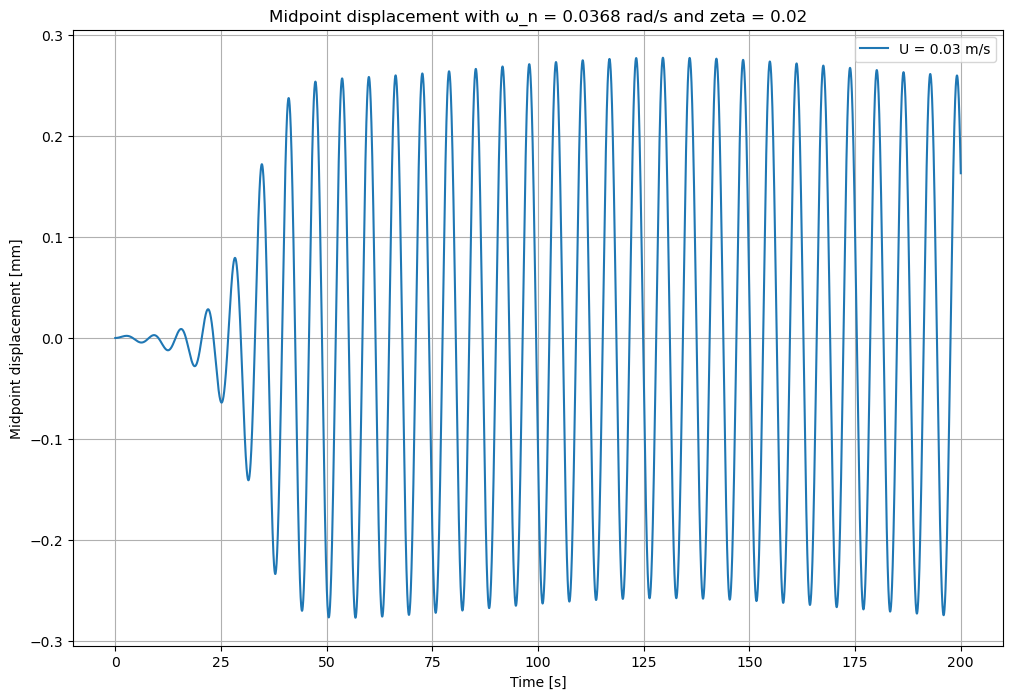

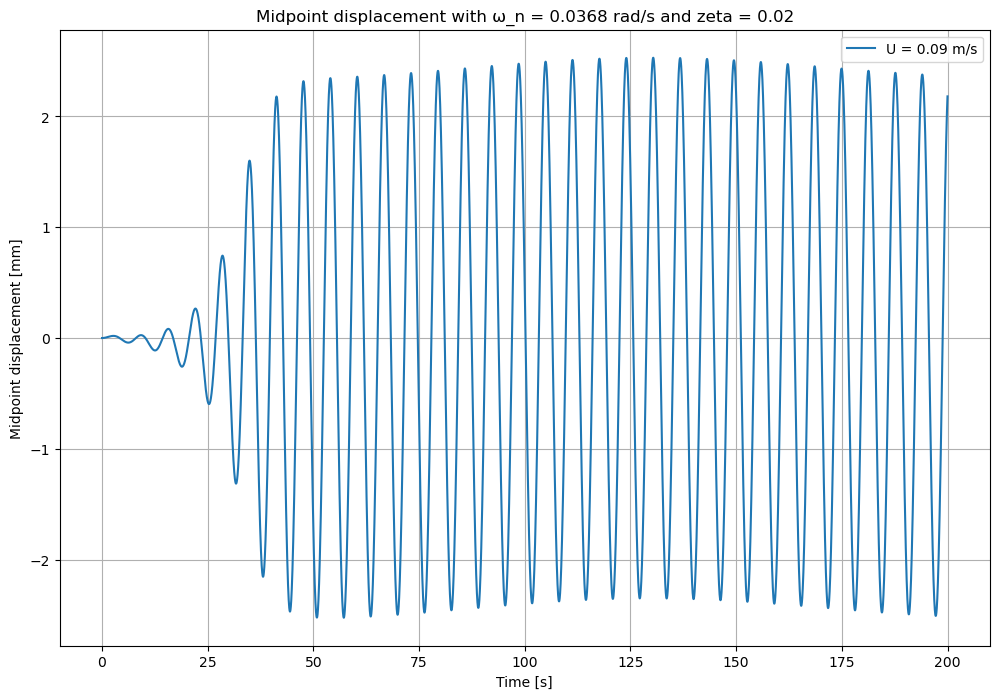

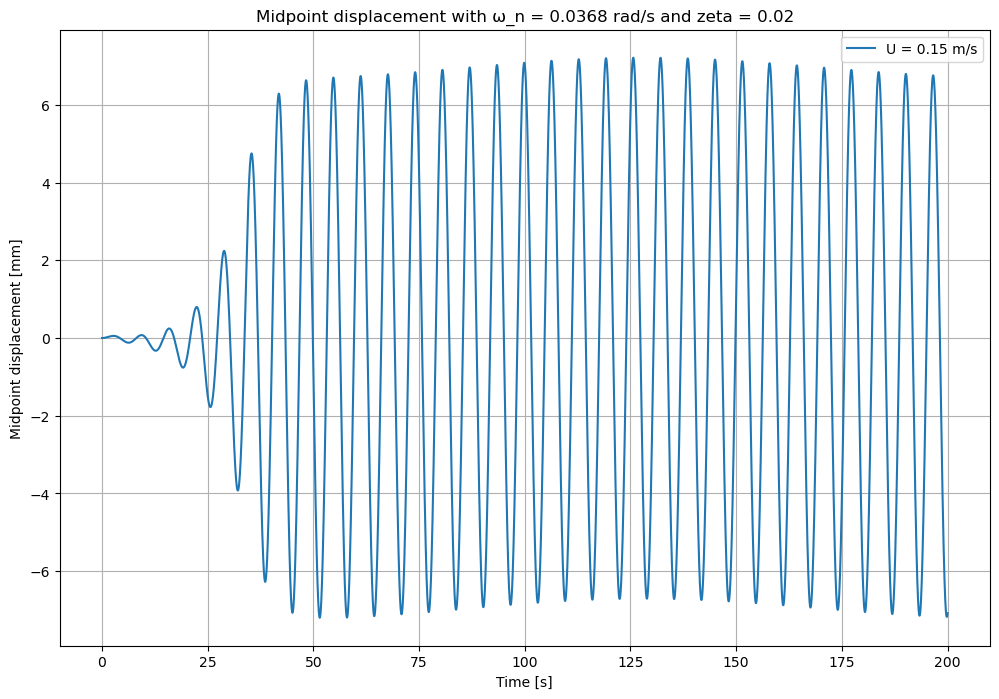

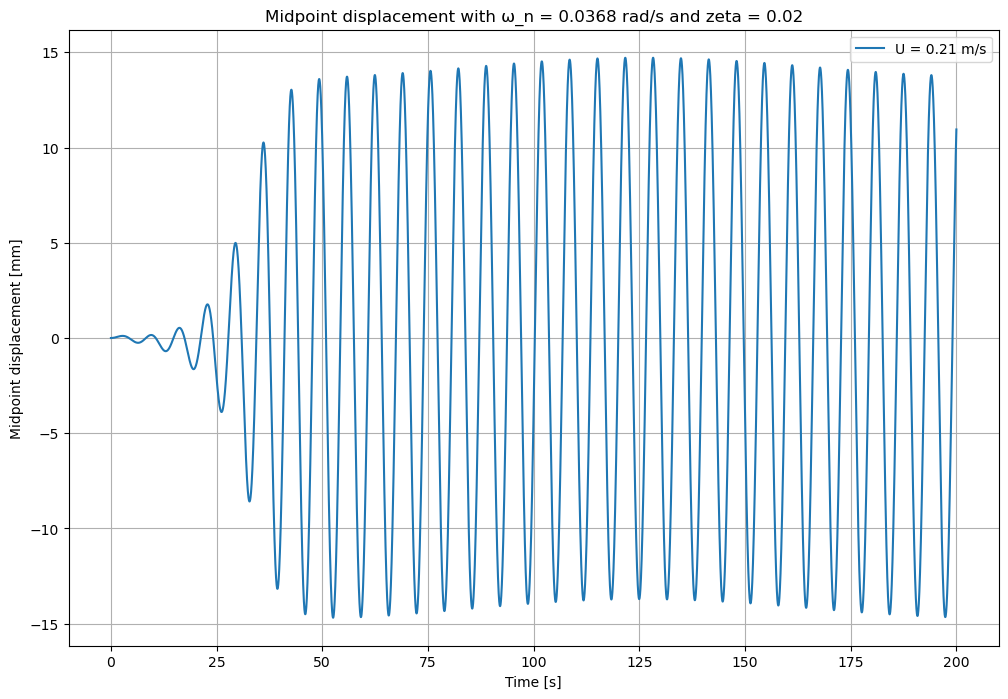

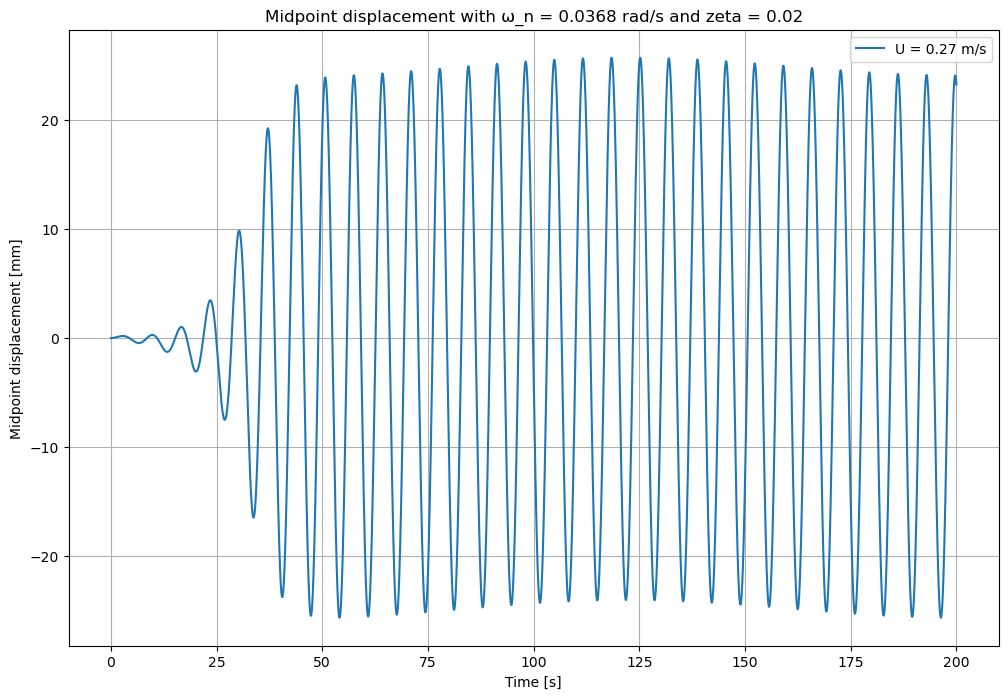

In [66]:
U_range = np.linspace(0.03, 0.27, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    dt = 0.01
    t_end = 200
    time, solution = comp_x(dt, t_end, U)
    plt.figure(figsize=(12,8))
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    plt.xlabel("Time [s]")
    plt.title(f"Midpoint displacement with \u03C9_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
    plt.ylabel("Midpoint displacement [mm]")
    plt.legend()
    plt.grid()

    print(f"Amplitude for U={U:.2f} m/s: {compute_amplitude(dt, t_end, U)*1000:.2f} mm")

end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")


Solving for U = 0.030
Solving for U = 0.048
Solving for U = 0.065
Solving for U = 0.083
Solving for U = 0.100


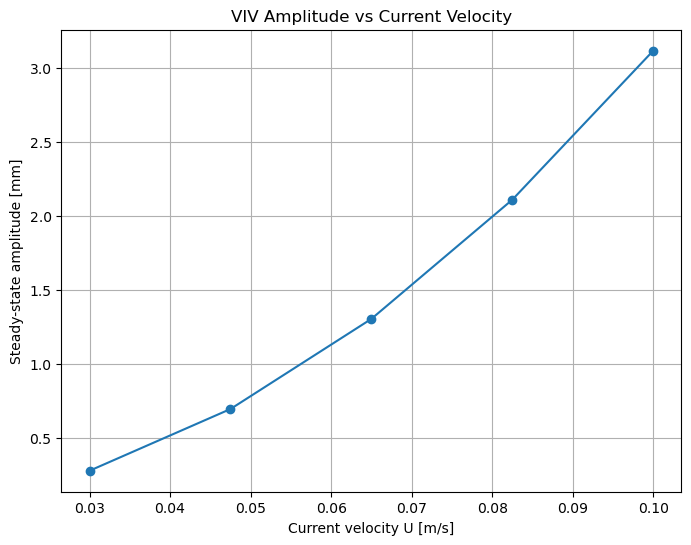

In [67]:
U_values = np.linspace(0.03, 0.10, 5)
amplitudes = []

for U in U_values:
    print(f"Solving for U = {U:.3f}")
    amp = compute_amplitude(dt , t_end, U)
    amplitudes.append(amp)

plt.figure(figsize=(8,6))
plt.plot(U_values, 1000 * np.array(amplitudes), marker='o')
plt.xlabel("Current velocity U [m/s]")
plt.ylabel("Steady-state amplitude [mm]")
plt.title("VIV Amplitude vs Current Velocity")
plt.grid(True)


Amplitude for U=0.03 m/s: 0.28 mm
Amplitude for U=0.09 m/s: 2.51 mm
Amplitude for U=0.15 m/s: 7.17 mm
Amplitude for U=0.21 m/s: 14.64 mm
Amplitude for U=0.27 m/s: 25.54 mm
Simulation completed in 4.97 seconds.


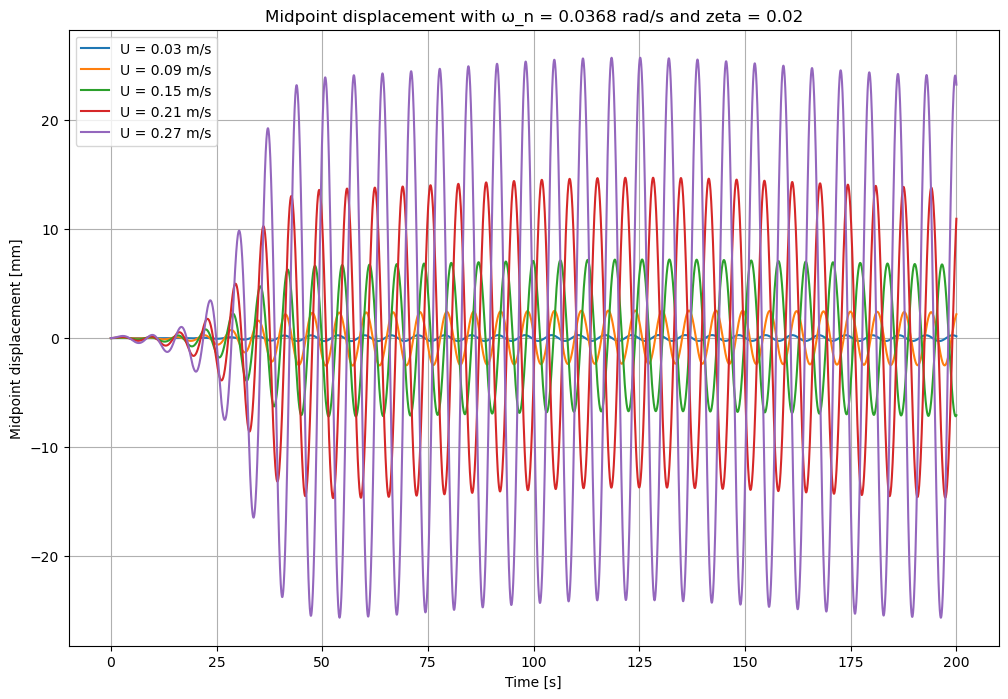

In [68]:
U_range = np.linspace(0.03, 0.27, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    dt = 0.01
    t_end = 200
    time, solution = comp_x(dt, t_end, U)
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    print(f"Amplitude for U={U:.2f} m/s: {compute_amplitude(dt, t_end, U)*1000:.2f} mm")

plt.xlabel("Time [s]")
plt.title(f"Midpoint displacement with \u03C9_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
plt.ylabel("Midpoint displacement [mm]")
plt.legend()
plt.grid()


end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")

# Dimensionless


In [291]:
L = 50.0
D = 0.5
rho_w = 1025
rho_c = 7880
T = 30000
b = 126
St = 0.21

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a
m_star = rho_c * A_cross 
m_a_star = rho_w * A_cross 
m_eff_star = m_star + m_a_star
omega_n1 = (np.pi / L)  * np.sqrt(T / m_eff_star)
print(f"Natural frequency (rad/s): {omega_n1:.4f}")

zeta = b / (2 * omega_n1 * m_eff_star)
f_n1 = omega_n1 / (2 *np.pi)
print(f"Natural frequency (Hz): {f_n1:.4f}")


epsilon = 0.2
A_coupling = 16.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0




Natural frequency (rad/s): 0.2603
Natural frequency (Hz): 0.0414


# Make variables dimensionless

In [279]:
def rhs(tau, x, U):
    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    omega_s = 2 * np.pi * St * U / D
    Omega_n = omega_n1 / omega_s

    hydro = (rho_w * D**2) / (m_eff_star * 8 * np.pi**2 * St**2)
    nonlinear_term = (-2 * np.pi * St * y_dot * Cx0_hat + ((Cy1_hat /q1_hat) * q))

    F = hydro * nonlinear_term * np.sqrt(1 + 4 * np.pi**2 * St**2 * y_dot**2)

    y_ddot = -2 * zeta * Omega_n * y_dot - Omega_n**2 * y + F
    q_ddot = -epsilon * (q**2 - 1) * q_dot - q + A_coupling * y_ddot

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [280]:
def rk4(f, tau, x, dt, U):

    k1 = f(tau, x, U)
    k2 = f(tau + dt/2, x + dt/2 * k1, U)
    k3 = f(tau + dt/2, x + dt/2 * k2, U)
    k4 = f(tau + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [287]:
def comp_x(U, x0):
    dtau = 0.005
    tau_end = 200
    tau = np.arange(0, tau_end, dtau)

    x = np.array(x0, dtype=float)
    solution = np.zeros((len(tau), 4))

    for i, tau_i in enumerate(tau):
        solution[i] = x
        x = rk4(rhs, tau_i, x, dtau, U)

    return tau, solution

In [282]:
def compute_amplitude(U):

    tau, solution = comp_x(U)
    y = solution[:,2]
    cutoff = int(0.9 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5*(np.max(y_steady) - np.min(y_steady))

    return amplitude

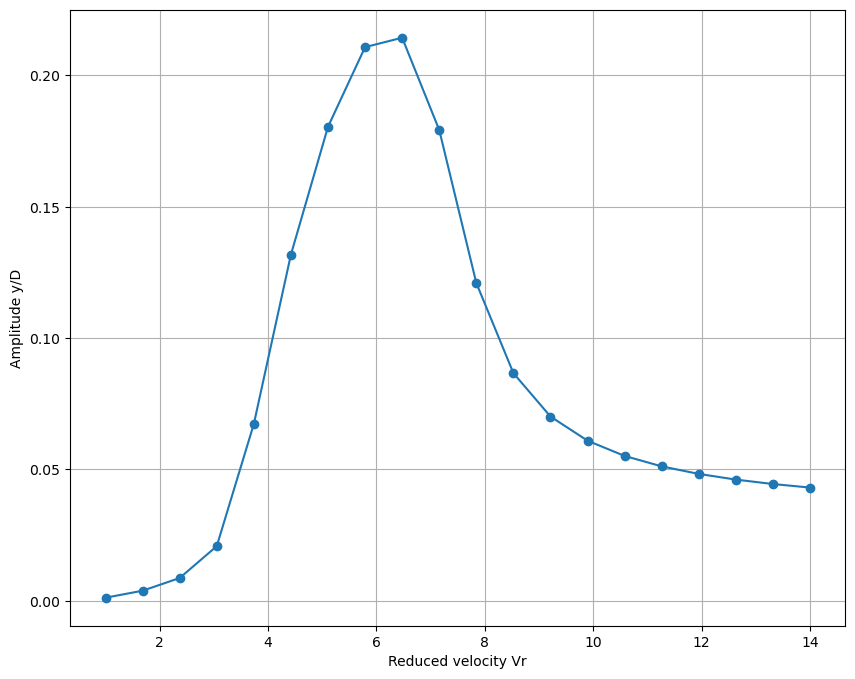

In [ ]:
V_r = np.linspace(1, 14, 40)
U_values = V_r * D * f_n1

amplitudes = []
x0 = np.array([0.01, 0.0, 0.0, 0.0])   # start once

for U in U_values:
    tau, solution = comp_x(U, x0)

    y = solution[:, 2]
    cutoff = int(0.85 * len(y))
    y_steady = y[cutoff:]
    amp = 0.5 * (np.max(y_steady) - np.min(y_steady))
    amplitudes.append(amp)

plt.figure(figsize=(10,8))
plt.plot(V_r, amplitudes, marker='o')
plt.xlabel("Reduced velocity Vr")
plt.ylabel("Amplitude y/D")
plt.grid()


In [271]:
print(U_values)


[0.02071089 0.02761452 0.03451815 0.04142178 0.04832541 0.05522904
 0.06213266 0.06903629 0.07593992 0.08284355 0.08974718 0.09665081
 0.10355444 0.11045807 0.1173617  0.12426533 0.13116896 0.13807259
 0.14497622 0.15187985 0.15878348 0.16568711 0.17259074 0.17949436
 0.18639799 0.19330162 0.20020525 0.20710888 0.21401251 0.22091614
 0.22781977 0.2347234  0.24162703 0.24853066 0.25543429 0.26233792
 0.26924155 0.27614518 0.28304881 0.28995244]


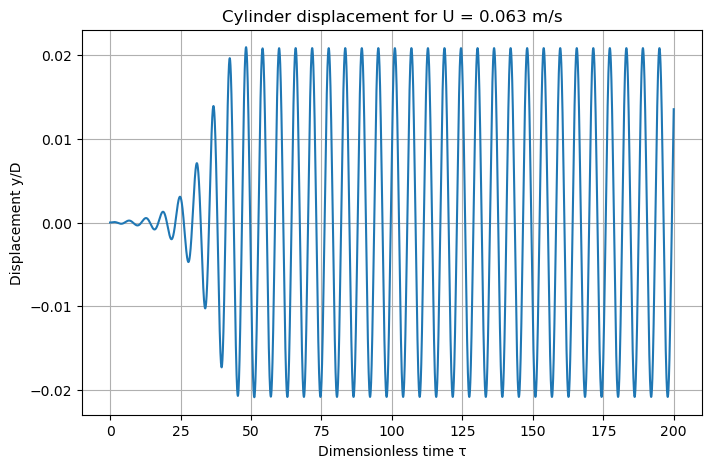

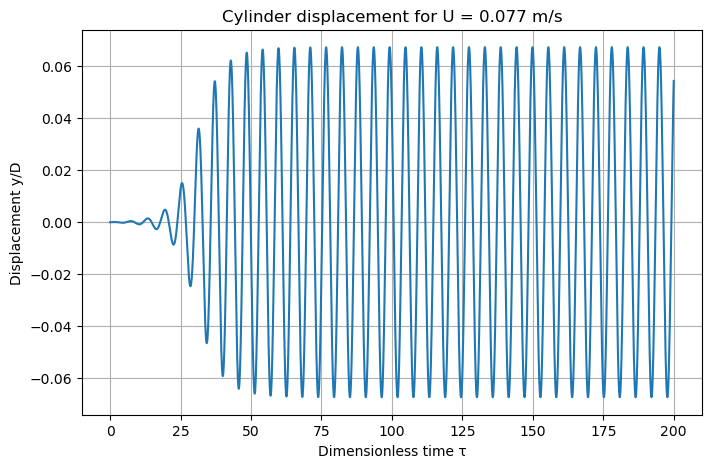

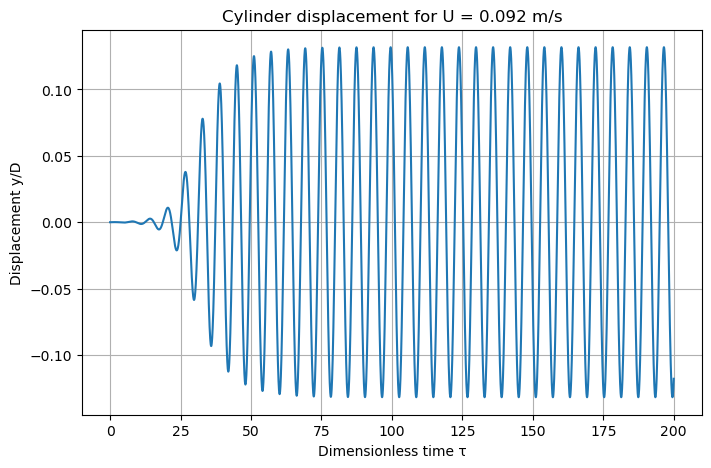

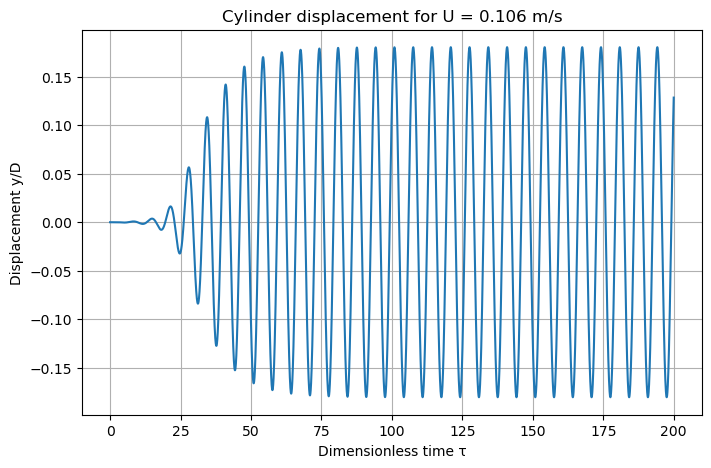

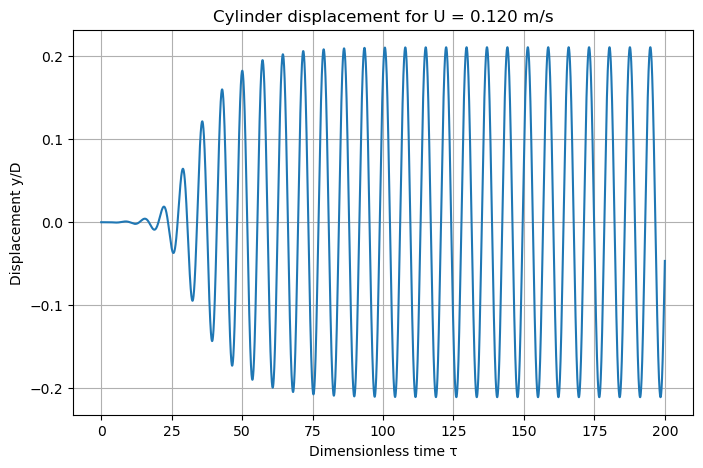

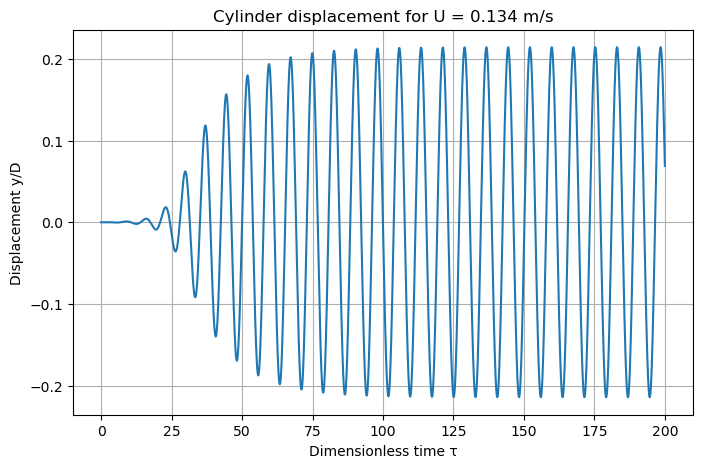

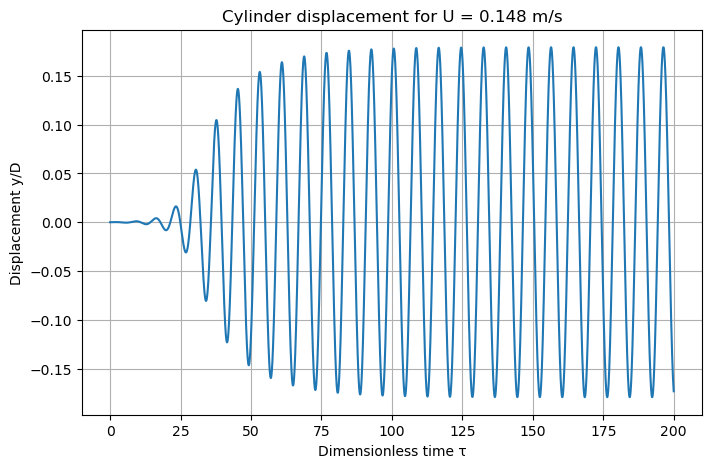

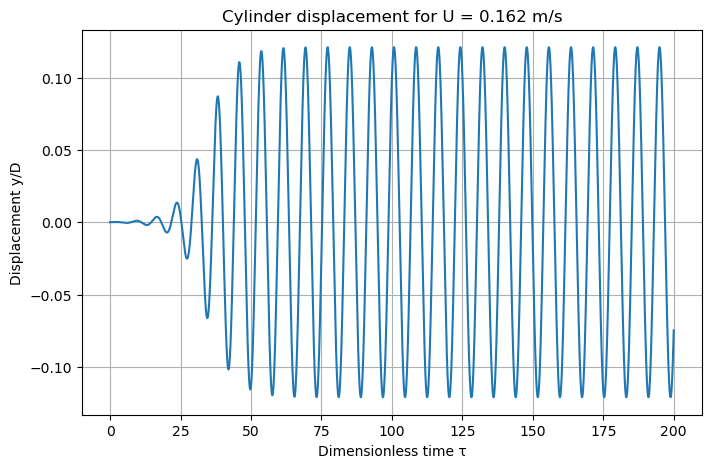

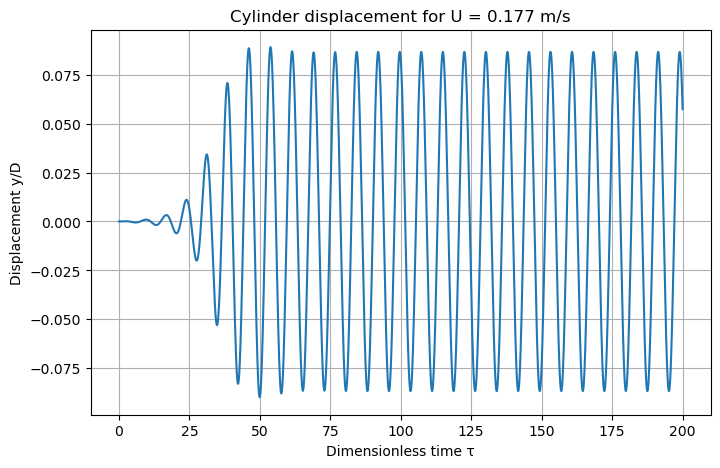

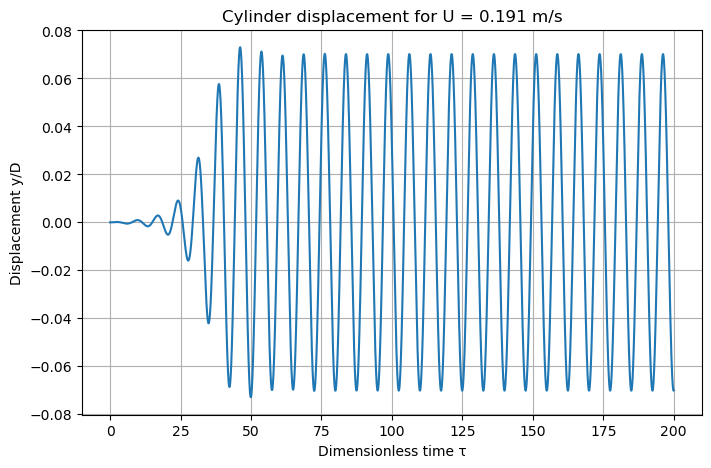

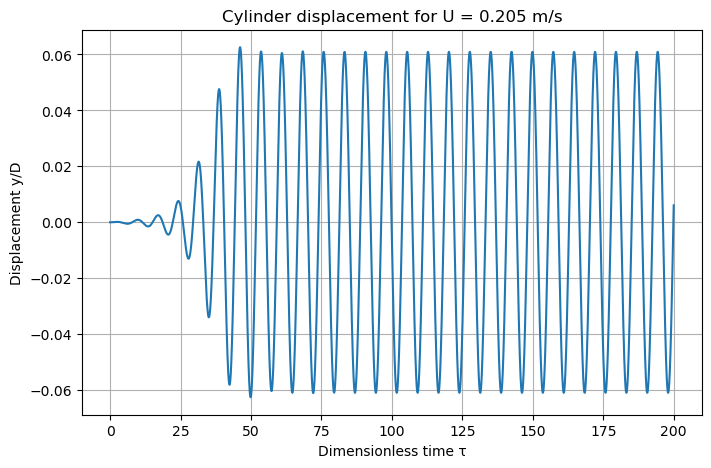

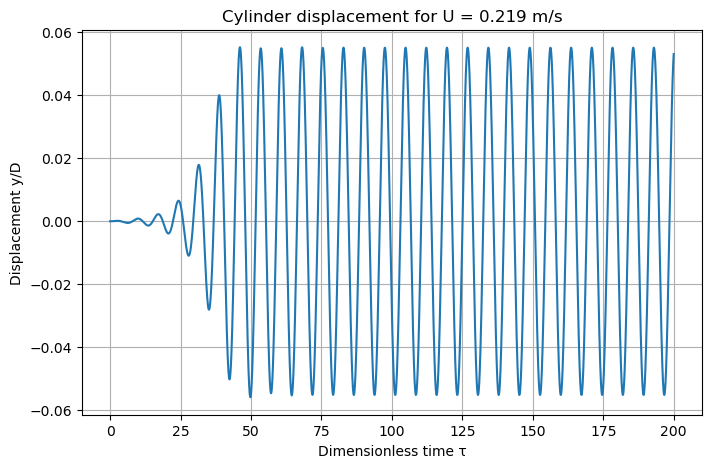

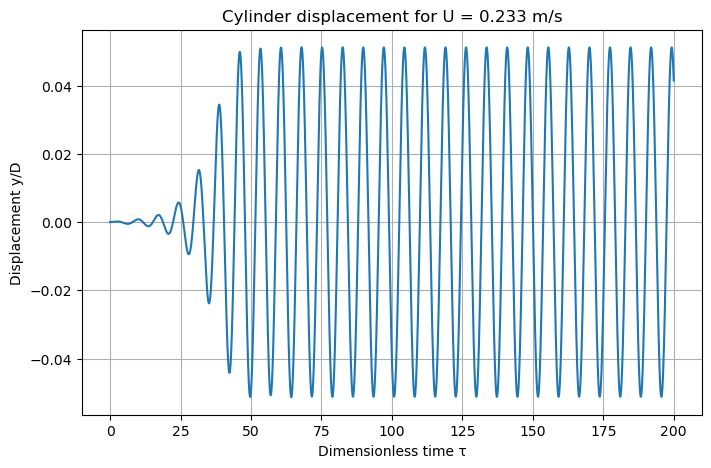

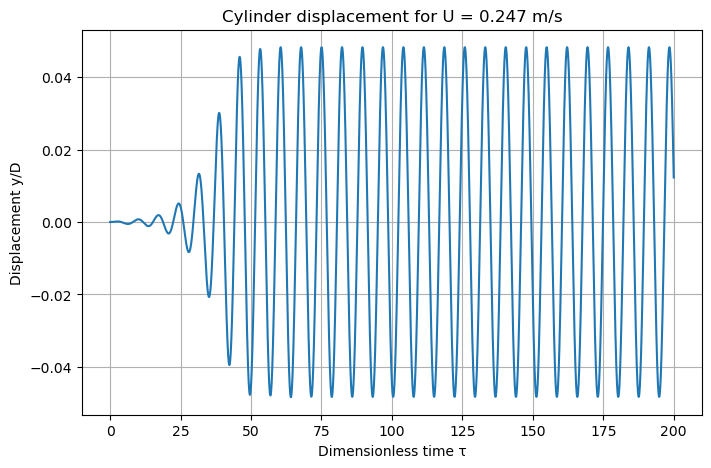

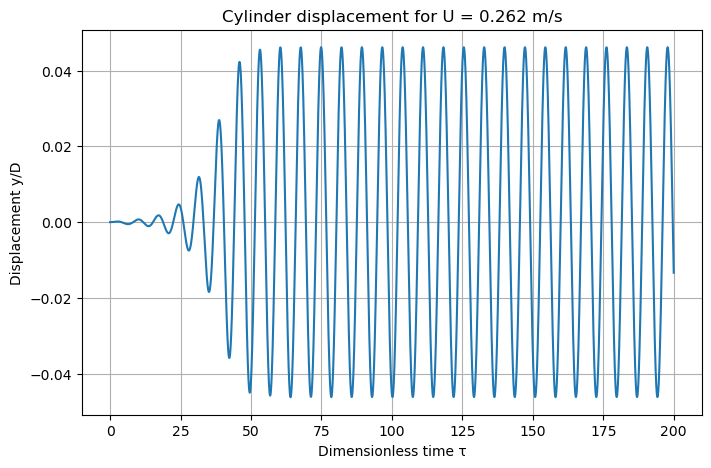

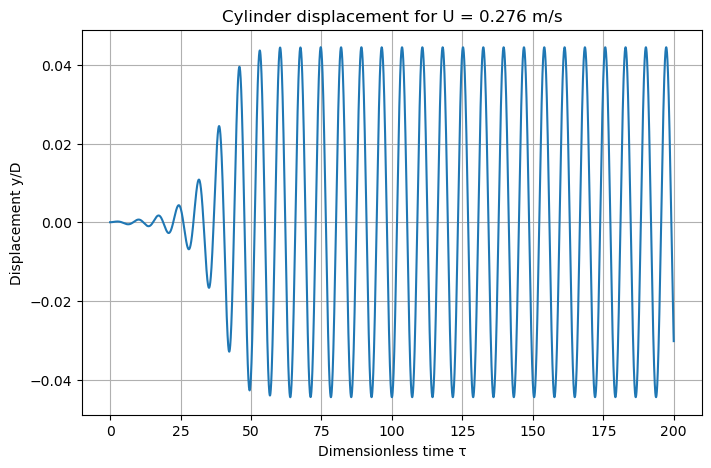

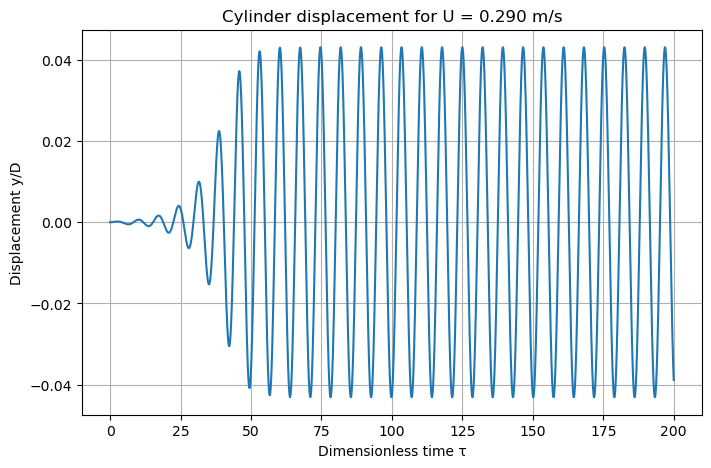

In [293]:
for U_i in U_values:

    if U_i > 0.05:
        tau, solution = comp_x(U_i, x0)

        y = solution[:,2]

        plt.figure(figsize=(8,5))
        plt.plot(tau, y)
        plt.xlabel("Dimensionless time τ")
        plt.ylabel("Displacement y/D")
        plt.title(f"Cylinder displacement for U = {U_i:.3f} m/s")
        plt.grid(True)
        plt.show()

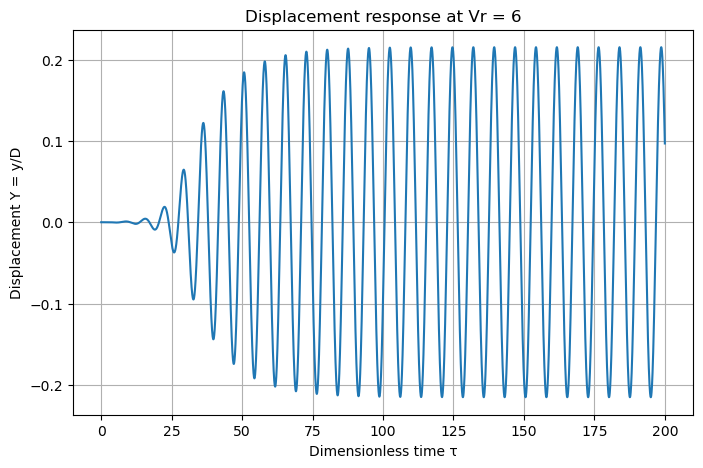

In [295]:
Vr_lockin = 6
U_lockin = Vr_lockin * f_n1 * D
tau, solution = comp_x(U_lockin, x0)

Y = solution[:,2]

plt.figure(figsize=(8,5))
plt.plot(tau, Y)
plt.xlabel("Dimensionless time τ")
plt.ylabel("Displacement Y = y/D")
plt.title(f"Displacement response at Vr = {Vr_lockin}")
plt.grid(True)
plt.show()


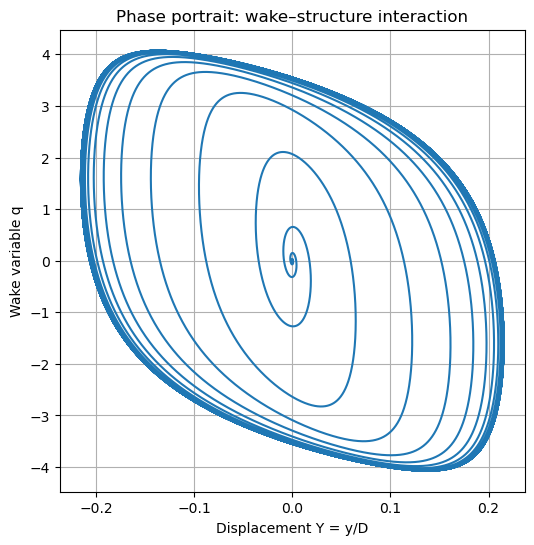

In [296]:
q = solution[:,0]
Y = solution[:,2]

plt.figure(figsize=(6,6))
plt.plot(Y, q)
plt.xlabel("Displacement Y = y/D")
plt.ylabel("Wake variable q")
plt.title("Phase portrait: wake–structure interaction")
plt.grid(True)
plt.show()